In [ ]:
import requests
import time
import os

# Load the API Token (necessary for Authorization)

In [ ]:
token = os.getenv('SPAYA_API_TOKEN')

# Run standard retrosynthesis on a molecule

In [ ]:
# define a function that takes a list of SMILES and Spaya parameters and return the API results

from typing import List

def run_retrosynthesis_batch(smiles_list: List, parameters_dict: dict={}):
    smiles_dict = {'smiles': smiles_list}
    payload = {**smiles_dict, **parameters_dict}
    response = requests.post(
        'https://spaya.ai/api/v2/retrosynthesis/batch',
        json = payload,
        headers={
            'Content-Type': 'application/json',
            'Authorization': f'Bearer {token}' # standard HTTP authentication for token-based APIs
        }
    )
    if not response.ok:
        print('Failed to submit retrosynthesis request')
        return None
    
    job_id = response.json()['jobId']
    print(f'Retrosynthesis submitted successfully. Job ID: {job_id}')

    while True:
        status_response = requests.get(
            f'https://spaya.ai/api/v2/retrosynthesis/{job_id}/status',
            headers={
                'Authorization': f'Bearer {token}'
            }
        )
        if not status_response.ok:
            print('Failed to get status')
            return None

        status_data = status_response.json()
        status = status_data['status']
        progress = status_data['progress']
        if status == 'DONE':
            break
        elif status == 'ERROR':
            print('Retrosynthesis failed')
            return None
        else:
            print(f'Retrosynthesis in status: {status} with progress: {progress}')
            time.sleep(10)  # Wait 10 seconds before next poll
    

    scores_response = requests.get(
        f'https://spaya.ai/api/v2/retrosynthesis/{job_id}/scores',
        headers={
            'Authorization': f'Bearer {token}'
        }
    )

    if not scores_response.ok:
        print('Failed to get scores')
        return None
    scores_data = scores_response.json()
    return scores_data


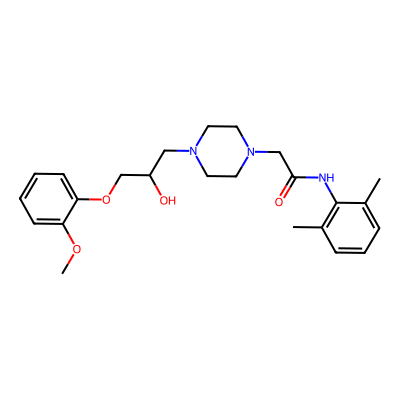

In [26]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

smiles = 'COc1ccccc1OCC(O)CN1CCN(CC(=O)Nc2c(C)cccc2C)CC1'

# Convert SMILES to molecule object
mol = Chem.MolFromSmiles(smiles)

# Display molecule
img = Draw.MolToImage(mol, size=(400, 400))
display(img)

In [27]:
run_retrosynthesis_batch(smiles_list=[smiles])

Retrosynthesis submitted successfully. Job ID: 365746


[{'smiles': 'COc1ccccc1OCC(O)CN1CCN(CC(=O)Nc2c(C)cccc2C)CC1',
  'score': 1,
  'nbSteps': 1,
  'status': 'DONE'}]

# Run batch retro on multiple molecules with advanced parameters

In [ ]:
import pandas as pd

data = pd.read_csv('data/sample_fragment_growing_data.csv')
data

,Makya ID,SMILES,QED,Similarity,Most Similar,Quality,Confidence,Scaffold,Isostere Score,Isostere Label,...,3D Pharmacophore 0.6 .. Inf,3D Shape 0.6 .. Inf,3D Combo score 0.6 .. Inf,MolLogP,MolWt,NumHAcceptors,NumHDonors,TPSA,Retrosynthesis Score,Retrosynthesis Steps
0,38466,CCCn1ncc(NC(=O)c2nc(-c3c(F)cccc3F)ccc2N)c1C(=O...,0.566763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.463772,0.629415,0.540283,4.09390,468.508,6,2,106.14,NaN,NaN
1,39786,Nc1ncc(-c2c(F)cccc2F)nc1C(=O)Nc1c(F)cnn1CC1CCOCC1,0.641804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.461260,0.667391,0.554834,3.01850,432.406,7,2,107.95,NaN,NaN
2,39890,Nc1ccc(-c2c(F)cccc2F)nc1C(=O)Nc1cnn(CCF)c1C(=O...,0.569735,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.478099,0.647166,0.556246,3.65340,472.471,6,2,106.14,NaN,NaN
3,41592,Nc1ccc(-c2c(F)cccc2F)nc1C(=O)Nc1cnn(CC(F)F)c1C...,0.509306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.478953,0.635061,0.551511,3.94900,490.461,6,2,106.14,NaN,NaN
4,41719,CCn1ncc(NC(=O)c2nc(-c3c(F)cccc3F)ccc2N)c1C(=O)...,0.611484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.472492,0.645203,0.552135,3.70380,454.481,6,2,106.14,NaN,NaN
5,42083,Cn1ncc(NCc2nc(-c3c(F)cccc3F)ccc2N)c1N1CCC[C@H]...,0.559192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.474771,0.699519,0.576291,3.12970,427.503,7,3,98.02,NaN,NaN
6,42102,Cn1ncc(NC(=O)c2nc(-c3c(F)cccc3F)ccc2N)c1C(=S)N...,0.581496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.464934,0.649361,0.549463,3.75620,456.522,6,2,89.07,NaN,NaN
7,42270,Cc1nn(CCF)c(C(=O)N2CCCCC2)c1NC(=O)c1nc(-c2c(F)...,0.548695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.478224,0.628679,0.548315,3.96182,486.498,6,2,106.14,NaN,NaN
8,42543,Nc1c(F)cc(-c2c(F)cccc2F)nc1C(=O)Nc1cccnc1N1CCC...,0.539240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.461698,0.676415,0.558837,3.74660,457.456,6,3,104.37,NaN,NaN
9,42758,Cc1cc(-c2c(F)cccc2F)nc(C(=O)Nc2cnn(CCF)c2C(=O)...,0.548695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.467536,0.625962,0.540981,3.96182,486.498,6,2,106.14,NaN,NaN


In [ ]:
smiles_list = data.SMILES.to_list()

results_batch = run_retrosynthesis_batch(
    smiles_list= smiles_list,
    parameters_dict={
        'maxPricePerG': 100,
        'maxDepth': 6,
        'removeChirality': True,
    }
)

results_batch


Retrosynthesis submitted successfully. Job ID: 365748
Retrosynthesis in status: PENDING with progress: 0
Retrosynthesis in status: PENDING with progress: 0
Retrosynthesis in status: PENDING with progress: 0
Retrosynthesis in status: PENDING with progress: 0
Retrosynthesis in status: PENDING with progress: 0
Retrosynthesis in status: PENDING with progress: 0
Retrosynthesis in status: RUNNING with progress: 0
Retrosynthesis in status: RUNNING with progress: 0
Retrosynthesis in status: RUNNING with progress: 0
Retrosynthesis in status: RUNNING with progress: 1
Retrosynthesis in status: RUNNING with progress: 1
Retrosynthesis in status: RUNNING with progress: 2
Retrosynthesis in status: RUNNING with progress: 2
Retrosynthesis in status: RUNNING with progress: 3
Retrosynthesis in status: RUNNING with progress: 3
Retrosynthesis in status: RUNNING with progress: 4
Retrosynthesis in status: RUNNING with progress: 4
Retrosynthesis in status: RUNNING with progress: 4
Retrosynthesis in status: RU

[{'smiles': 'Nc1c(F)cc(-c2c(F)cccc2F)nc1C(=O)Nc1cnn(CCF)c1C(=O)N1CCCCC1',
  'score': 0.6292645,
  'nbSteps': 5,
  'status': 'DONE'},
 {'smiles': 'CNC[C@H]1CCCN(c2c(NCc3nc(-c4c(F)cccc4F)ccc3N)cnn2C)C1',
  'score': 0.8433785,
  'nbSteps': 6,
  'status': 'DONE'},
 {'smiles': 'CCn1ncc(NC(=O)c2nc(-c3c(F)cccc3F)cc(C)c2N)c1C(=O)N1CCCCC1',
  'score': 0.36132783,
  'nbSteps': 6,
  'status': 'DONE'},
 {'smiles': 'Cc1cc(-c2c(F)cccc2F)nc(C(=O)Nc2cnn(CCF)c2C(=O)N2CCCCC2)c1N',
  'score': 0.6373359,
  'nbSteps': 5,
  'status': 'DONE'},
 {'smiles': 'Nc1ccc(-c2c(F)cccc2F)nc1C(=O)Nc1cnn(CCF)c1C(=O)N1CCCC(F)C1',
  'score': 0.88284487,
  'nbSteps': 6,
  'status': 'DONE'},
 {'smiles': 'Cn1ncc(NCc2nc(-c3c(F)cccc3F)ccc2N)c1N1CCCCC(N)C1',
  'score': 0.87880725,
  'nbSteps': 6,
  'status': 'DONE'},
 {'smiles': 'Cn1ncc(NC(=O)c2nc(-c3c(F)cccc3F)ccc2N)c1N1CCCCC(N)C1',
  'score': 0.8904939,
  'nbSteps': 4,
  'status': 'DONE'},
 {'smiles': 'Nc1ccc(-c2c(F)cccc2F)nc1C(=O)Nc1cnn(CCF)c1C(=O)N1CCC(F)CC1',
  'score': 0.8

## Visualization and analysis

### Distribution of RScore and NSteps

In [34]:
df_results = pd.DataFrame(results_batch)
df_results.head()


,smiles,score,nbSteps,status
0,Nc1c(F)cc(-c2c(F)cccc2F)nc1C(=O)Nc1cnn(CCF)c1C...,0.629265,5,DONE
1,CNC[C@H]1CCCN(c2c(NCc3nc(-c4c(F)cccc4F)ccc3N)c...,0.843379,6,DONE
2,CCn1ncc(NC(=O)c2nc(-c3c(F)cccc3F)cc(C)c2N)c1C(...,0.361328,6,DONE
3,Cc1cc(-c2c(F)cccc2F)nc(C(=O)Nc2cnn(CCF)c2C(=O)...,0.637336,5,DONE
4,Nc1ccc(-c2c(F)cccc2F)nc1C(=O)Nc1cnn(CCF)c1C(=O...,0.882845,6,DONE


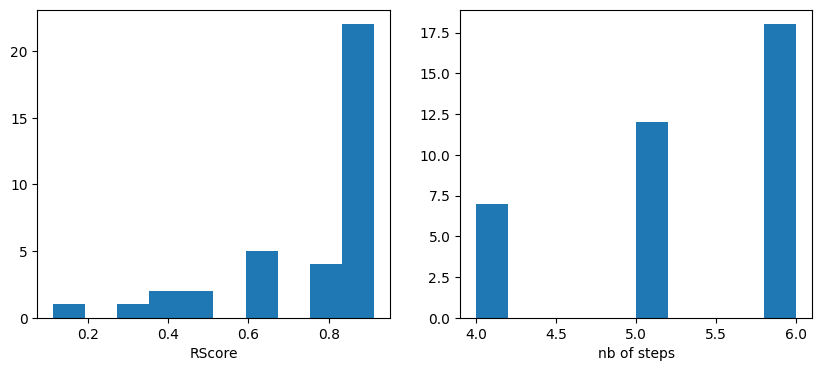

In [41]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df_results['score'])
plt.xlabel('RScore')
plt.subplot(1,2,2)
plt.hist(df_results['nbSteps'])
plt.xlabel('nb of steps')
plt.show()

### Synthetic route information 

In [ ]:
job_id = 365748
smiles = df_results.loc[df_results['score'].idxmax(), 'smiles']

# Request synthetic routes for a specific SMILES (the one with highest RScore in the dataset)
response = requests.get(
    f"https://spaya.ai/api/v2/retrosynthesis/{job_id}/target/{smiles}/page/1",
    headers={
        "Authorization": f"Bearer {token}"
    }
)

# Checks status code of response
print(response.status_code)


200


In [ ]:
data = response.json()
routes = data['routes'] # List all the routes from the response
best_route = routes[0] # Take the best route - highest RScore, top of the routes list
best_route

{'hashId': 'ec7da8cf10f41af8aa10e3ca386c480977ccfcd2e14c955f51c183b455561c40',
 'score': 0.9113837,
 'aiScore': 0.41866192,
 'hammerScore': 0.93388045,
 'similarity': 0.74756736,
 'clusterFirstSplit': 'eyJwcm9kdWN0X3NtaWxlcyI6ICJDQzFDQ0NOKEMoPU8pYzJjKE5DKD1PKWMzbmMoLWM0YyhGKWNjY2M0RiljY2MzTiljbm4yQ0NGKUMxIiwgImF0b21zX3RvX2hpZ2hsaWdodCI6IFsxMCwgMTFdLCAiYm9uZHNfdG9faGlnaGxpZ2h0IjogWzEwXX0=',
 'clusterKeyCuts': 'eyJwcm9kdWN0X3NtaWxlcyI6ICJDQzFDQ0NOKEMoPU8pYzJjKE5DKD1PKWMzbmMoLWM0YyhGKWNjY2M0RiljY2MzTiljbm4yQ0NGKUMxIiwgImF0b21zX3RvX2hpZ2hsaWdodCI6IFtbNSwgNl0sIFsxMCwgMTFdLCBbMTUsIDE2XV0sICJib25kc190b19oaWdobGlnaHQiOiBbWzVdLCBbMTBdLCBbMTVdXX0=',
 'price': None,
 'chemoRegioScore': 1,
 'scoreNameReac': 0.9816621693413762,
 'unfinishedRoute': False,
 'steps': [{'id': '89640efa6dd0cafe18c2a2d54d1219b02d20496e382d8dd0432140ec61d92e5b',
   'parentId': None,
   'rule': '[C&H0&+0:1]-[N&H1&+0:2]>>[C&H0&+0:1]-[O&H1&D1&+0].[N&H2&+0:2]',
   'smiles': 'CC1CCCN(C(=O)c2c(NC(=O)c3nc(-c4c(F)cccc4F)ccc3N)cnn

### Retrosynthesis tree

In [ ]:
# Display a synthesis tree for the best route 

from collections import defaultdict

steps = best_route["steps"] 

# map node_id → node
nodes = {step["id"]: step for step in steps}

# build adjacency list (parent → children)
tree = defaultdict(list)

root = None

for step in steps:
    parent = step["parentId"]
    if parent is None:
        root = step["id"]
    else:
        tree[parent].append(step["id"])

def print_tree(node_id, tree, nodes, depth=0):
    node = nodes[node_id]

    indent = "    " * depth
    print(f"{indent}- {node['smiles']}")

    for child_id in tree[node_id]:
        print_tree(child_id, tree, nodes, depth + 1)

print_tree(root, tree, nodes)

- CC1CCCN(C(=O)c2c(NC(=O)c3nc(-c4c(F)cccc4F)ccc3N)cnn2CCF)C1
    - Nc1ccc(-c2c(F)cccc2F)nc1C(=O)O
        - COC(=O)c1nc(-c2c(F)cccc2F)ccc1N
            - COC(=O)c1nc(Br)ccc1N
            - OB(O)c1c(F)cccc1F
    - CC1CCCN(C(=O)c2c(N)cnn2CCF)C1
        - Nc1cnn(CCF)c1C(=O)O
        - CC1CCCNC1


# List all available reactions

In [ ]:
response = requests.get(
    "https://spaya.ai/api/v2/name-reactions/list",
    headers={
        "Authorization": f"Bearer {token}"
    }
)
df_name_reactions = pd.DataFrame(response.json())
df_name_reactions.head()

,category,subCategory,name
0,C-C bond formation,Other organometallic C-C bond formation,"[1,1,1]Propellane synthesis"
1,Heterocycle synthesis,S-containing heterocycle formation,"1,1-Dioxothiomorpholine synthesis"
2,Heterocycle synthesis,N-containing heterocycle formation,"1,2,3,4-tetrahydro-1,4-diazepine-5-one synthesis"
3,Heterocycle synthesis,O-containing heterocycle formation,"1,2,3-Oxadiazole synthesis"
4,Heterocycle synthesis,Other heterocycle forming reactions,"1,2,3-Selenadiazole synthesis"


# List all commercial providers

In [60]:
response = requests.get(
    "https://spaya.ai/api/v2/providers/list",
    headers={
        "Authorization": f"Bearer {token}"
    }
)
df_providers = pd.DataFrame(response.json())
df_providers.head()

,name,displayName
0,10xchem,10X Chem
1,1-plus-chem,1PlusChem
2,a2b-chem,A2B Chem
3,aa-blocks,AA Blocks
4,accela-chembio,Accela ChemBio


In [61]:
len(df_providers)

45

# Search commercial compounds by SMILES

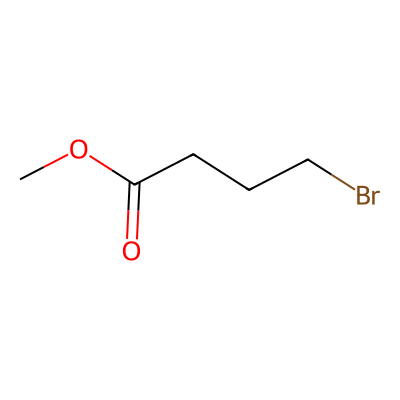

In [63]:
smiles_bb = "COC(=O)CCCBr"  # example molecule


# Convert SMILES to molecule object
mol = Chem.MolFromSmiles(smiles_bb)

# Display molecule
img = Draw.MolToImage(mol, size=(400, 400))
display(img)

In [77]:
response = requests.post(
    "https://spaya.ai/api/v2/commercial-compounds/list/smiles",
    json={
        "smiles": [smiles_bb],
        "limit": 5
    },
    headers={
        "Content-Type": "application/json",
        "Authorization": f"Bearer {token}"
    }
)

# Note: you can also run a search by inchikey instead of smiles,
# replacing the URL by: 
# https://spaya.ai/api/v2/commercial-compounds/list/inchikey

print(response.status_code)

200


In [76]:
df_bb = pd.DataFrame(response.json())
df_bb.head()

,moleculeId,packagingG,pricePerG,provider,purity,url,cas,catalog,description,deliveryDateMin,deliveryDateMax,smiles,reference
0,F214657-1G,1,5.2800,fluorochem,95,https://fluorochem.co.uk/product/F214657,4897-84-1,building block,Methyl 4-bromobutanoate,7,7,COC(=O)CCCBr,None
1,F214657-10G,10,0.7040,fluorochem,95,https://fluorochem.co.uk/product/F214657,4897-84-1,building block,Methyl 4-bromobutanoate,14,14,COC(=O)CCCBr,None
2,F214657-25G,25,0.2816,fluorochem,95,https://fluorochem.co.uk/product/F214657,4897-84-1,building block,Methyl 4-bromobutanoate,1,1,COC(=O)CCCBr,None
3,F214657-5G,5,1.4080,fluorochem,95,https://fluorochem.co.uk/product/F214657,4897-84-1,building block,Methyl 4-bromobutanoate,14,14,COC(=O)CCCBr,None
4,F214657-100G,100,0.1936,fluorochem,95,https://fluorochem.co.uk/product/F214657,4897-84-1,building block,Methyl 4-bromobutanoate,1,1,COC(=O)CCCBr,None
